# 멕스웰 방정식, 음함수 미분법, 미적분학의 기본정리 (뉴진수 9강)-11강 3기 09강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, t = sp.symbols("x t", real=True)

## 1. 음함수의 해집합 위에서 항등식 읽기
$F(x,y)=x^3+y^3-6xy$. 해집합 $F=0$ 위에서는 전미분이 $0$ 이므로
$F_x\,dx+F_y\,dy=0$, 따라서 그 곡선의 기울기는 $\dfrac{dy}{dx}=-\dfrac{F_x}{F_y}$.

In [2]:
y = sp.symbols("y", real=True)
F = x**3 + y**3 - 6 * x * y
Fx, Fy = sp.diff(F, x), sp.diff(F, y)
dydx = sp.simplify(-Fx / Fy)
print("F(x,y)   =", F)
print("F_x      =", Fx)
print("F_y      =", Fy)
print("dy/dx    = -F_x/F_y =", dydx)

# point on the curve: (3, 3) satisfies F = 0
P = {x: 3, y: 3}
print("F(3,3)   =", F.subs(P), "  -> on the solution set")
print("slope at (3,3) =", dydx.subs(P))

F(x,y)   = x**3 - 6*x*y + y**3
F_x      = 3*x**2 - 6*y
F_y      = -6*x + 3*y**2
dy/dx    = -F_x/F_y = (x**2 - 2*y)/(2*x - y**2)
F(3,3)   = 0   -> on the solution set
slope at (3,3) = -1


## 2. 정적분과 부정적분은 왜 연결되는가
FTC: 미분하면 $f$ 가 되는 $F$ 를 찾으면 $\displaystyle\int_a^b f\,dx=F(b)-F(a)$.
강의의 작은 예 $\displaystyle\int_0^1 x^2\,dx=\tfrac13$ 을 부정적분과 면적 정의 양쪽으로 확인합니다.

In [3]:
f = x**2
F_anti = sp.integrate(f, x)                       # antiderivative x^3/3
val = sp.integrate(f, (x, 0, 1))                  # definite integral
print("antiderivative F(x) =", F_anti)
print("F(1) - F(0)         =", (F_anti.subs(x, 1) - F_anti.subs(x, 0)))
print("∫_0^1 x^2 dx        =", val)

# a few more antiderivative / FTC checks from the note's function zoo
for g in [sp.sin(x), sp.cos(x), sp.exp(x), x**5]:
    G = sp.integrate(g, x)
    print(f"  d/dx [{str(G):>14}] = {sp.diff(G, x)}   (recovers {g})")

antiderivative F(x) = x**3/3
F(1) - F(0)         = 1/3
∫_0^1 x^2 dx        = 1/3
  d/dx [       -cos(x)] = sin(x)   (recovers sin(x))
  d/dx [        sin(x)] = cos(x)   (recovers cos(x))
  d/dx [        exp(x)] = exp(x)   (recovers exp(x))
  d/dx [        x**6/6] = x**5   (recovers x**5)


## 3. 리만합: 면적을 직사각형으로 채우기
구간을 $n$ 등분해 직사각형 넓이를 더한 리만합
$\displaystyle\sum_{k} f(x_k)\,\Delta x$ 이 $n\to\infty$ 에서 $\int_0^1 x^2\,dx=\tfrac13$ 로 수렴함을 확인합니다.

In [4]:
def riemann(func, a, b, n, rule="left"):
    xs = np.linspace(a, b, n + 1)
    dx = (b - a) / n
    if rule == "left":
        samp = xs[:-1]
    elif rule == "right":
        samp = xs[1:]
    else:  # midpoint
        samp = (xs[:-1] + xs[1:]) / 2
    return np.sum(func(samp)) * dx

g = lambda s: s**2
exact = 1 / 3
print(f"exact  ∫_0^1 x^2 dx = {exact:.6f}")
print(f"{'n':>6} {'left':>12} {'right':>12} {'midpoint':>12}")
for n in [2, 4, 8, 16, 64, 256, 1024]:
    L = riemann(g, 0, 1, n, "left")
    R = riemann(g, 0, 1, n, "right")
    M = riemann(g, 0, 1, n, "mid")
    print(f"{n:>6} {L:>12.6f} {R:>12.6f} {M:>12.6f}")

exact  ∫_0^1 x^2 dx = 0.333333
     n         left        right     midpoint
     2     0.125000     0.625000     0.312500
     4     0.218750     0.468750     0.328125
     8     0.273438     0.398438     0.332031
    16     0.302734     0.365234     0.333008
    64     0.325562     0.341187     0.333313
   256     0.331383     0.335289     0.333332
  1024     0.332845     0.333822     0.333333


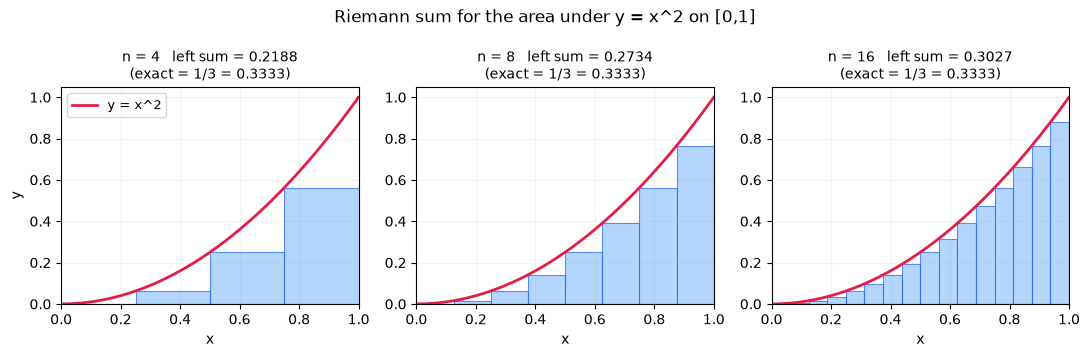

In [5]:
# Visualize the left-Riemann rectangles approaching the area under y = x^2.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
xs_fine = np.linspace(0, 1, 400)
for ax, n in zip(axes, [4, 8, 16]):
    edges = np.linspace(0, 1, n + 1)
    dx = 1 / n
    left = edges[:-1]
    ax.bar(left, left**2, width=dx, align="edge",
           color="#93c5fd", edgecolor="#2563eb", alpha=0.7, linewidth=0.8)
    ax.plot(xs_fine, xs_fine**2, color="#e11d48", lw=2, label="y = x^2")
    approx = riemann(g, 0, 1, n, "left")
    ax.set_title(f"n = {n}   left sum = {approx:.4f}\n(exact = 1/3 = {exact:.4f})", fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_xlabel("x"); ax.grid(alpha=0.15)
axes[0].set_ylabel("y")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Riemann sum for the area under y = x^2 on [0,1]", fontsize=12)
fig.tight_layout()
plt.show()

## 5. 면적 함수의 미분으로 보는 FTC
$A(x)=\displaystyle\int_a^x f(t)\,dt$ 의 도함수가 원래 함수 $f$ 라는 FTC 의 한 방향을
$f(t)=t^2,\ a=0$ 으로 확인합니다: $A(x)=\tfrac{x^3}{3}$, $A'(x)=x^2=f(x)$.

In [6]:
A = sp.integrate(t**2, (t, 0, x))
print("A(x) = ∫_0^x t^2 dt =", A)
print("A'(x)             =", sp.diff(A, x), "  ( = f(x) = x^2 )")

# numeric difference-quotient sanity check  (A(x+h)-A(x))/h -> f(x)
A_num = sp.lambdify(x, A, "numpy")
x0 = 0.7
for h in [1e-1, 1e-2, 1e-3, 1e-4]:
    dq = (A_num(x0 + h) - A_num(x0)) / h
    print(f"  h={h:7.0e}:  (A(x+h)-A(x))/h = {dq:.6f}   vs  f(x)=x^2 = {x0**2:.6f}")

A(x) = ∫_0^x t^2 dt = x**3/3
A'(x)             = x**2   ( = f(x) = x^2 )


  h=  1e-01:  (A(x+h)-A(x))/h = 0.563333   vs  f(x)=x^2 = 0.490000
  h=  1e-02:  (A(x+h)-A(x))/h = 0.497033   vs  f(x)=x^2 = 0.490000
  h=  1e-03:  (A(x+h)-A(x))/h = 0.490700   vs  f(x)=x^2 = 0.490000
  h=  1e-04:  (A(x+h)-A(x))/h = 0.490070   vs  f(x)=x^2 = 0.490000


## 7. 무한히 더한다는 말과 망원경 합
$F(b)-F(a)=\displaystyle\sum_{k=1}^n\big(F(x_k)-F(x_{k-1})\big)$ 는 중간 항이 모두 상쇄되는
망원경 합이고, 각 조각 $F(x_k)-F(x_{k-1})\approx F'(x_{k-1})\,\Delta x$ 의 합이 정적분으로 갑니다.

In [7]:
# telescoping: the partition sum of differences collapses to the endpoint difference, exactly.
Fexpr = x**3 / 3                          # antiderivative of x^2
Fnum = sp.lambdify(x, Fexpr, "numpy")
a, b = 0.0, 1.0
for n in [3, 10, 100]:
    nodes = np.linspace(a, b, n + 1)
    tele = np.sum(Fnum(nodes[1:]) - Fnum(nodes[:-1]))    # sum of F(x_k)-F(x_{k-1})
    print(f"n={n:>4}:  Σ (F(x_k)-F(x_(k-1))) = {tele:.10f}   F(b)-F(a) = {Fnum(b)-Fnum(a):.10f}")

# and each piece F'(x_{k-1})·Δx (left rule) approximates that telescoping sum
print("\napprox by F'(x_(k-1))·Δx  (this is the Riemann sum of f=F'):")
fprime = lambda s: s**2
for n in [3, 10, 100, 1000]:
    print(f"  n={n:>5}:  Σ F'(x_(k-1))Δx = {riemann(fprime, a, b, n, 'left'):.6f}   -> F(b)-F(a) = {Fnum(b)-Fnum(a):.6f}")

n=   3:  Σ (F(x_k)-F(x_(k-1))) = 0.3333333333   F(b)-F(a) = 0.3333333333
n=  10:  Σ (F(x_k)-F(x_(k-1))) = 0.3333333333   F(b)-F(a) = 0.3333333333
n= 100:  Σ (F(x_k)-F(x_(k-1))) = 0.3333333333   F(b)-F(a) = 0.3333333333

approx by F'(x_(k-1))·Δx  (this is the Riemann sum of f=F'):
  n=    3:  Σ F'(x_(k-1))Δx = 0.185185   -> F(b)-F(a) = 0.333333
  n=   10:  Σ F'(x_(k-1))Δx = 0.285000   -> F(b)-F(a) = 0.333333
  n=  100:  Σ F'(x_(k-1))Δx = 0.328350   -> F(b)-F(a) = 0.333333
  n= 1000:  Σ F'(x_(k-1))Δx = 0.332834   -> F(b)-F(a) = 0.333333


## 8. 적분 계산의 세 단계와 원시함수의 어려움
잘 아는 함수는 원시함수를 찾지만, $e^{-x^2},\ \sin x/x,\ \sin(x^2)$ 는 초등함수 원시함수가 없습니다.
또 같은 도함수를 갖는 두 원시함수는 상수만큼만 다릅니다: $(F-G)'=0\Rightarrow F-G=\text{const}$.

In [8]:
# SymPy returns non-elementary special functions (erf, Si, Fresnel) -> no elementary antiderivative
for g in [sp.exp(-x**2), sp.sin(x) / x, sp.sin(x**2)]:
    print(f"∫ {str(g):>10} dx = {sp.integrate(g, x)}")

# uniqueness up to a constant: two antiderivatives of x^2 differ by a constant
F1, F2 = x**3 / 3, x**3 / 3 + 7
print("\n(F1 - F2)' =", sp.diff(F1 - F2, x), "  ->  F1 - F2 =", sp.simplify(F1 - F2), "(a constant)")

∫ exp(-x**2) dx = sqrt(pi)*erf(x)/2


∫   sin(x)/x dx = Si(x)


∫  sin(x**2) dx = 3*sqrt(2)*sqrt(pi)*fresnels(sqrt(2)*x/sqrt(pi))*gamma(3/4)/(8*gamma(7/4))

(F1 - F2)' = 0   ->  F1 - F2 = -7 (a constant)


## 9. 상수 $C$ 와 정적분의 양끝값
부정적분의 상수 $C$ 는 정적분에서 사라집니다:
$(F(b)+C)-(F(a)+C)=F(b)-F(a)$. 어떤 원시함수를 잡아도 정적분 값은 같습니다.

In [9]:
C = sp.symbols("C")
for Fc in [x**3 / 3, x**3 / 3 + C, x**3 / 3 - 5]:
    definite = Fc.subs(x, 1) - Fc.subs(x, 0)
    print(f"F(x) = {str(Fc):>12}:   F(1)-F(0) = {sp.simplify(definite)}")

F(x) =       x**3/3:   F(1)-F(0) = 1/3
F(x) =   C + x**3/3:   F(1)-F(0) = 1/3
F(x) =   x**3/3 - 5:   F(1)-F(0) = 1/3


## 10. $e^x$, 로그, 그리고 테일러 급수로 넘어가는 이유
$e^x$ 는 미분해도 자기 자신. 원시함수를 모르는 적분은 테일러 급수로 항별 적분합니다.
예: $e^{-x^2}=\sum\frac{(-1)^k x^{2k}}{k!}$ 를 항별 적분하면 $\int_0^1 e^{-x^2}dx$ 를 얻습니다.

In [10]:
print("d/dx e^x =", sp.diff(sp.exp(x), x), "  (its own derivative)")

# Taylor series of e^{-x^2}, integrate term by term on [0,1]
series = sp.series(sp.exp(-x**2), x, 0, 12).removeO()
print("e^{-x^2} ≈", series)
term_by_term = sp.integrate(series, (x, 0, 1))
exact_val = sp.integrate(sp.exp(-x**2), (x, 0, 1))     # (sqrt(pi)/2) erf(1)
print("∫_0^1 (series) dx      =", sp.nsimplify(term_by_term), "≈", float(term_by_term))
print("∫_0^1 e^{-x^2} dx exact =", exact_val, "≈", float(exact_val))

d/dx e^x = exp(x)   (its own derivative)
e^{-x^2} ≈ -x**10/120 + x**8/24 - x**6/6 + x**4/2 - x**2 + 1
∫_0^1 (series) dx      = 31049/41580 ≈ 0.7467291967291967
∫_0^1 e^{-x^2} dx exact = sqrt(pi)*erf(1)/2 ≈ 0.746824132812427


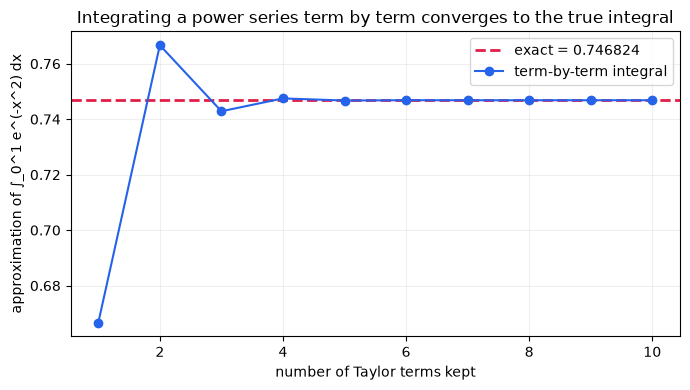

In [11]:
# how the term-by-term integral converges to the true value as we keep more terms
fig, ax = plt.subplots(figsize=(7, 4))
orders = range(1, 11)
partials = []
for N in orders:
    ser = sp.series(sp.exp(-x**2), x, 0, 2 * N + 1).removeO()
    partials.append(float(sp.integrate(ser, (x, 0, 1))))
true = float(exact_val)
ax.axhline(true, color="#e11d48", lw=2, ls="--", label=f"exact = {true:.6f}")
ax.plot(list(orders), partials, "o-", color="#2563eb", label="term-by-term integral")
ax.set_xlabel("number of Taylor terms kept")
ax.set_ylabel("approximation of ∫_0^1 e^(-x^2) dx")
ax.set_title("Integrating a power series term by term converges to the true integral")
ax.grid(alpha=0.2); ax.legend()
fig.tight_layout()
plt.show()